# Modeling — Linear Regression & Regularization

## Context
This notebook is the third step in the modeling pipeline for the
[Ames Housing dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques).
It consumes the clean, model-ready files exported by `02_Features.ipynb`:
`X_train.csv` (1458 × 205), `X_test.csv` (1459 × 205), `y_train.csv`
(log-transformed target), and `test_ids.csv`.

The feature engineering notebook handled all data cleaning, encoding, skewness
correction, and feature selection. The only remaining preprocessing step is
feature scaling (standardization), which is applied here inside a scikit-learn
Pipeline to prevent data leakage during cross-validation.

This notebook focuses exclusively on linear models. Tree-based models
(Random Forest, Gradient Boosting, XGBoost) will be explored in
`04_Modeling_Trees.ipynb`.

## Objectives
- Set up a reproducible evaluation framework (K-Fold CV, RMSE in log space)
- Establish a baseline with ordinary linear regression
- Train regularized models (Ridge, Lasso, ElasticNet) with built-in hyperparameter search
- Compare all models on CV performance and analyze residuals of the best one
- Generate a Kaggle submission file from the best linear model

## Table of Contents
1. [Imports & Data Loading](#1-imports-data-loading)
2. [Evaluation Framework](#2-evaluation-framework)
3. [Linear Regression](#3-linear-regression)
4. [Ridge Regression (L2)](#4-ridge-regression)
5. [Lasso Regression (L1)](#5-lasso-regression)
6. [ElasticNet (L1 + L2)](#6-elasticnet)
7. [Model Comparison](#7-model-comparison)
8. [Residual Analysis](#8-residual-analysis)
9. [Kaggle Submission](#9-kaggle-submission)

## 1. Imports & Data Loading <a id="1-imports-data-loading"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
DATA_DIR = "../data/processed"

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
test_ids = pd.read_csv(f"{DATA_DIR}/test_ids.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  (min={y_train.min():.2f}, max={y_train.max():.2f})")
print(f"test_ids: {test_ids.shape}")

X_train : (1458, 205)
X_test  : (1459, 205)
y_train : (1458,)  (min=10.46, max=13.53)
test_ids: (1459,)


## 2. Evaluation Framework <a id="2-evaluation-framework"></a>

All models are evaluated with 5-fold cross-validation using RMSE in log space,
which is equivalent to the Kaggle leaderboard metric (RMSLE) since the target
was log-transformed in `02_Features.ipynb`.

Each model is wrapped in a Pipeline with `StandardScaler` to ensure that scaling
is fitted only on training folds — never on the validation fold — preventing
data leakage.

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, label="Model"):
    """Evaluate a model with K-Fold CV inside a StandardScaler pipeline.
    
    Returns the array of per-fold RMSE scores (in log space = RMSLE).
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-scores)
    
    print(f"{label:<20} RMSE: {rmse_scores.mean():.5f} (+/- {rmse_scores.std():.5f})")
    
    return rmse_scores

## 3. Linear Regression <a id="3-baseline-linear-regression"></a>

Ordinary Least Squares with no regularization. With 205 features for 1,458
observations (~7:1 ratio), the model is expected to overfit and produce unstable
coefficients. This serves as a reference point for regularized models.

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_scores = evaluate_model(lr, X_train, y_train, label="LinearRegression")

LinearRegression     RMSE: 0.12674 (+/- 0.01315)


## 4. Ridge Regression (L2) <a id="4-ridge-regression"></a>

Ridge adds an L2 penalty (λ × Σβⱼ²) that shrinks coefficients toward zero
without eliminating any. `RidgeCV` handles alpha selection via internal
cross-validation; the external CV in `evaluate_model` provides an unbiased
performance estimate.

In [5]:
from sklearn.linear_model import RidgeCV

alphas_ridge = np.logspace(-3, 3, 100)

ridge = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_scores = evaluate_model(ridge, X_train, y_train, label="RidgeCV")

RidgeCV              RMSE: 0.12145 (+/- 0.00932)


In [6]:
pipe_ridge = Pipeline([("scaler", StandardScaler()), ("model", ridge)])
pipe_ridge.fit(X_train, y_train)

print(f"Best alpha: {pipe_ridge.named_steps['model'].alpha_:.4f}")

Best alpha: 70.5480


## 5. Lasso Regression (L1) <a id="5-lasso-regression"></a>

Lasso adds an L1 penalty (λ × Σ|βⱼ|) that can shrink coefficients to exactly
zero, performing automatic feature selection. With 205 features (many from
one-hot encoding), this property is particularly relevant.

In [7]:
from sklearn.linear_model import LassoCV

alphas_lasso = np.logspace(-4, 0, 100)

lasso = LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000, random_state=42)
lasso_scores = evaluate_model(lasso, X_train, y_train, label="LassoCV")

LassoCV              RMSE: 0.11896 (+/- 0.00915)


In [8]:
pipe_lasso = Pipeline([("scaler", StandardScaler()), ("model", lasso)])
pipe_lasso.fit(X_train, y_train)

lasso_coefs = pipe_lasso.named_steps["model"].coef_
n_kept = np.sum(lasso_coefs != 0)
n_dropped = np.sum(lasso_coefs == 0)

print(f"Best alpha: {pipe_lasso.named_steps['model'].alpha_:.6f}")
print(f"Features kept:    {n_kept} / {X_train.shape[1]}")
print(f"Features dropped: {n_dropped}")

Best alpha: 0.003430
Features kept:    87 / 205
Features dropped: 118


## 6. ElasticNet (L1 + L2) <a id="6-elasticnet"></a>

ElasticNet combines L1 and L2 penalties. The `l1_ratio` parameter controls the
mix: 1.0 = pure Lasso, 0.0 = pure Ridge. By blending both, ElasticNet inherits
Lasso's feature selection while handling correlated features more stably than
Lasso alone.

In [9]:
from sklearn.linear_model import ElasticNetCV

alphas_enet = np.logspace(-4, 0, 50)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

enet = ElasticNetCV(
    alphas=alphas_enet,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000,
    random_state=42,
)
enet_scores = evaluate_model(enet, X_train, y_train, label="ElasticNetCV")

ElasticNetCV         RMSE: 0.11905 (+/- 0.00915)


In [10]:
pipe_enet = Pipeline([("scaler", StandardScaler()), ("model", enet)])
pipe_enet.fit(X_train, y_train)

print(f"Best alpha:    {pipe_enet.named_steps['model'].alpha_:.6f}")
print(f"Best l1_ratio: {pipe_enet.named_steps['model'].l1_ratio_}")
print(f"Features kept: {np.sum(pipe_enet.named_steps['model'].coef_ != 0)} / {X_train.shape[1]}")

Best alpha:    0.003556
Best l1_ratio: 0.95
Features kept: 89 / 205


ElasticNet converges to an almost pure Lasso solution (`l1_ratio=0.95`), with
comparable performance (0.1190 vs 0.1190) and a similar number of retained
features (89 vs 87). The L2 component adds no meaningful benefit here: the
correlated features identified in EDA were already handled during feature
selection in `02_Features.ipynb`, leaving Lasso's sparsity as the dominant
driver of performance.

For this dataset, Lasso provides the best trade-off between accuracy, stability,
and simplicity among linear models. ElasticNet remains a valid default in
contexts where feature correlations are not addressed upstream.

## 7. Model Comparison <a id="7-model-comparison"></a>

Side-by-side comparison of all four linear models on CV performance (mean RMSE
and stability) to select the best candidate for residual analysis and Kaggle
submission.

In [12]:
results = {
    "LinearRegression": lr_scores,
    "Ridge": ridge_scores,
    "Lasso": lasso_scores,
    "ElasticNet": enet_scores,
}

comparison = pd.DataFrame({
    name: {"Mean RMSE": scores.mean(), "Std": scores.std(), "Min": scores.min(), "Max": scores.max()}
    for name, scores in results.items()
}).T.sort_values("Mean RMSE")

comparison

,Mean RMSE,Std,Min,Max
Lasso,0.1190,0.0091,0.1014,0.1270
ElasticNet,0.1191,0.0091,0.1015,0.1270
Ridge,0.1214,0.0093,0.1029,0.1279
LinearRegression,0.1267,0.0131,0.1069,0.1483


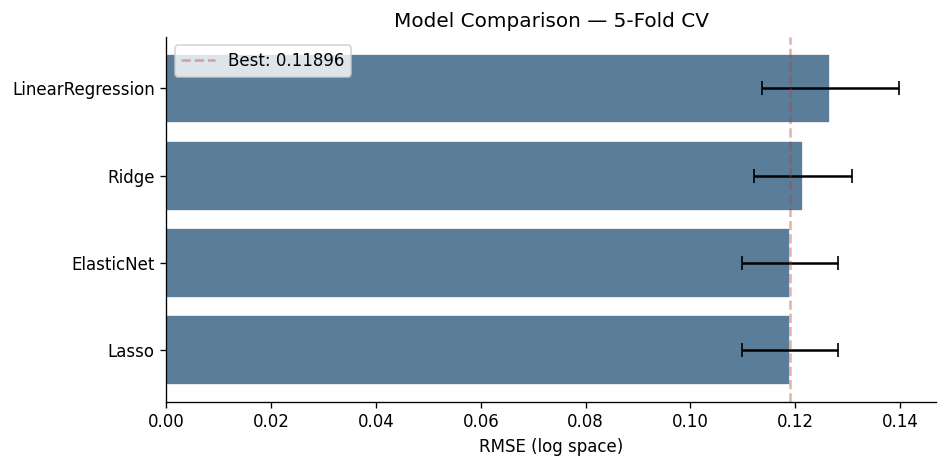

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

names = list(results.keys())
means = [s.mean() for s in results.values()]
stds  = [s.std() for s in results.values()]

order = np.argsort(means)
names = [names[i] for i in order]
means = [means[i] for i in order]
stds  = [stds[i] for i in order]

bars = ax.barh(names, means, xerr=stds, color="#5a7d9a", edgecolor="white", capsize=4)
ax.set_xlabel("RMSE (log space)")
ax.set_title("Model Comparison — 5-Fold CV")
ax.axvline(x=means[0], color="#c0392b", linestyle="--", alpha=0.4, label=f"Best: {means[0]:.5f}")
ax.legend()

plt.tight_layout()
plt.show()

## 8. Residual Analysis <a id="8-residual-analysis"></a>

Diagnostic plots for the best linear model (Lasso). Residuals are computed on
the full training set after fitting on all data. This is not an evaluation
(that was done via CV) but a diagnostic to identify systematic patterns in the
errors.

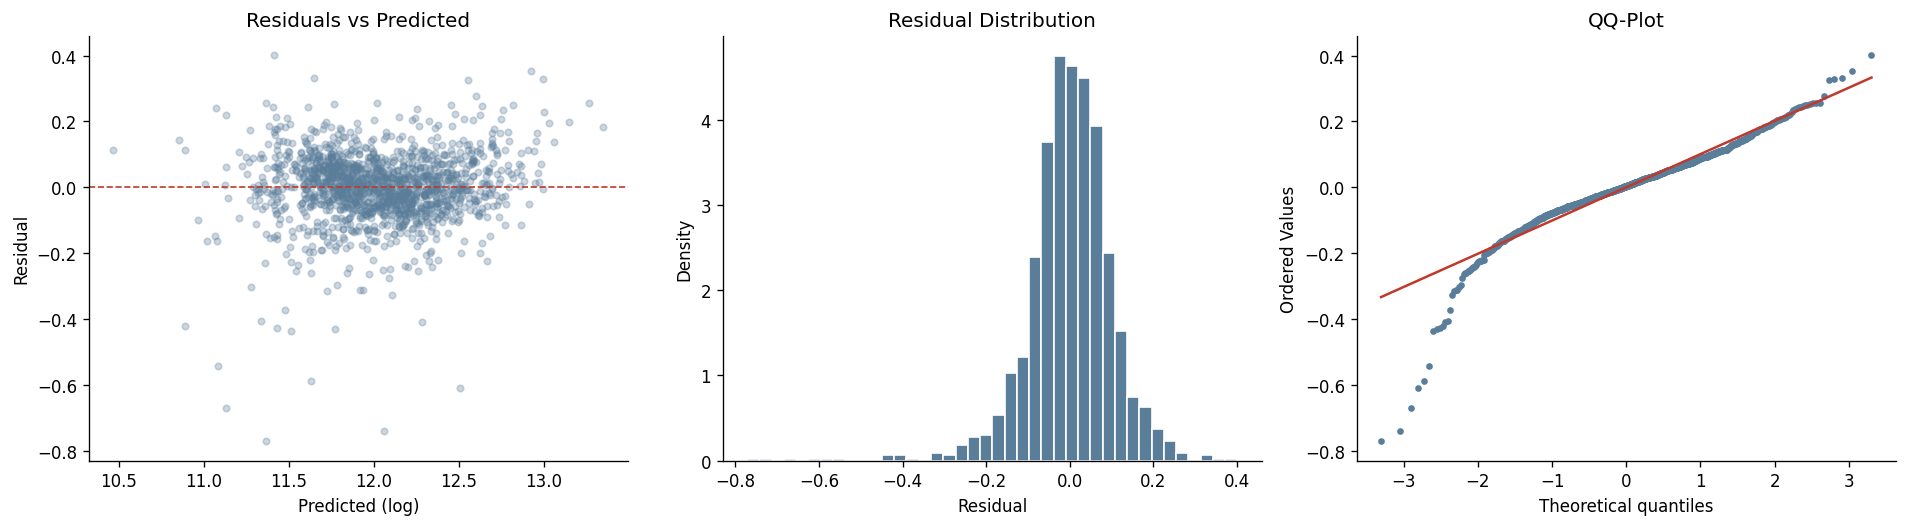

Residuals — mean: 0.000000, std: 0.1051, skew: -1.2689


In [14]:
y_pred_log = pipe_lasso.predict(X_train)
residuals = y_train - y_pred_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred_log, residuals, alpha=0.3, s=15, color="#5a7d9a")
axes[0].axhline(y=0, color="#c0392b", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted (log)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# 2. Residual Distribution
axes[1].hist(residuals, bins=40, color="#5a7d9a", edgecolor="white", density=True)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual Distribution")

# 3. QQ-Plot
from scipy import stats
stats.probplot(residuals, plot=axes[2])
axes[2].set_title("QQ-Plot")
axes[2].get_lines()[0].set(color="#5a7d9a", markersize=3)
axes[2].get_lines()[1].set(color="#c0392b")

plt.tight_layout()
plt.show()

print(f"Residuals — mean: {residuals.mean():.6f}, std: {residuals.std():.4f}, "
      f"skew: {residuals.skew():.4f}")

The residual analysis confirms that Lasso produces well-behaved errors overall:
centered at zero, approximately normal in the core distribution, and with no
visible systematic pattern in the residuals-vs-predicted plot.

However, two signals suggest room for improvement. The negative skewness
(−1.27) and the QQ-plot deviations at both tails reveal a subset of
observations — likely atypical or high-value properties — where the linear
model consistently overpredicts. These heavy-tailed errors are beyond what
regularization alone can fix: they reflect non-linear relationships that a
linear model cannot capture by design.

This diagnostic motivates the next step in the pipeline. Tree-based models
(Random Forest, Gradient Boosting, XGBoost) in `04_Modeling_Trees.ipynb` can
learn the kind of non-linear splits needed to handle these cases, and are
expected to reduce both the tail errors and the overall RMSE.

## 9. Kaggle Submission <a id="9-kaggle-submission"></a>

Final predictions are generated using the Lasso model fitted on the full
training set. Since the model predicts in log space, `expm1` reverses the
`log1p` transformation applied in `02_Features.ipynb` to recover prices in
dollars.

In [15]:
y_test_log = pipe_lasso.predict(X_test)
y_test_prices = np.expm1(y_test_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_prices,
})

print(f"Submission shape: {submission.shape}")
print(f"Price range: ${y_test_prices.min():,.0f} — ${y_test_prices.max():,.0f}")
print(f"\n{submission.head(10)}")

Submission shape: (1459, 2)
Price range: $48,042 — $693,119

     Id   SalePrice
0  1461 111494.2857
1  1462 159480.6089
2  1463 179864.4860
3  1464 197792.3994
4  1465 199277.4856
5  1466 171401.8090
6  1467 178622.5231
7  1468 162039.7728
8  1469 195765.6682
9  1470 115006.0780


In [16]:
submission.to_csv("../submissions/submission_lasso.csv", index=False)
print("Saved to ../submissions/submission_lasso.csv")

Saved to ../submissions/submission_lasso.csv


## Summary

This notebook evaluated four linear models on the Ames Housing dataset (1,458
observations, 205 features):

| Model | CV RMSE (log) | Std | Features used |
|-------|--------------|-----|---------------|
| Linear Regression | 0.12674 | 0.01315 | 205 |
| Ridge (L2) | 0.12145 | 0.00932 | 205 |
| **Lasso (L1)** | **0.11896** | **0.00915** | **87** |
| ElasticNet (L1+L2) | 0.11905 | 0.00915 | 89 |

Lasso emerged as the best linear model, achieving the lowest RMSE while using
fewer than half of the available features. The regularization path told a clear
story: the dataset benefits more from feature elimination (L1 sparsity) than
from coefficient shrinkage alone (L2).

Residual analysis revealed that while errors are well-behaved overall, a subset
of atypical properties produces heavy-tailed residuals that a linear model
cannot address. This motivates the transition to tree-based models in
`04_Modeling_Trees.ipynb`, which can capture the non-linear relationships needed
to reduce these tail errors.